# 043 卷积局部性与平移结构

本Notebook从头真实重算手算账本、七项平移探针和80步核学习；先阅读lecture和lab。源文件与数据摘要防止无意混用版本。CPU float64，无下载、无API。

In [1]:
from pathlib import Path
import os, sys, json, hashlib, tempfile
candidates = [Path.cwd(), Path.cwd() / 'units' / '043']
ROOT = next((p.resolve() for p in candidates if (p/'experiment.py').is_file() and (p/'data/experiment_data.json').is_file()), None)
if ROOT is None:
    raise RuntimeError('请从043单元目录或课程仓库根启动Notebook')
os.environ.setdefault('MPLCONFIGDIR', str(ROOT/'../../tmp/043-nb-mpl'))
os.environ.setdefault('XDG_CACHE_HOME', str(ROOT/'../../tmp/043-nb-cache'))
sys.path.insert(0, str(ROOT))
expected = {'experiment.py': 'a8b302af65eea6a95a6818576ad7236284b170a0bdd84e688e47adc6bf05b5c4', 'test_experiment.py': 'fc1b0b0e03e321b8e0e56d660f7bf1836be3f22099610467db997283bad2e868', 'generate_data.py': '06d0297731852637d5028e807dbd1d3d820d05ec27edaceb896d824832362f08', 'make_figures.py': '228b1465de03f566d905a6613d941fd0a8530f535897b0aa1b26e068ca9a57a2', 'data/experiment_data.json': 'ec1c96566aaf6a13f6a6366ffaf3aab696ef3d31278676e5b1f419e092912f13', 'data/data_manifest.json': 'c1ed068c8cbd7413fb8fe81b8802378e006a3b5ae7f385d0fad48752024213a5', 'outputs/results.json': '2a155fcf39ca6d97ffecb49ad63966b4cc4aa68f9af914de6bb34c67e80685ce', 'figures/01_window.png': '16529a0913a53185fcf9a2978d5bf811d8b805c5cc1146084e2e36c22c3f7a84', 'figures/02_sharing.png': 'b13a9f83267a71a31b27425c34802342077888d421659b8c32bfc70b0eeba5e4', 'figures/03_geometry.png': '473f8afaa210d56ffd711062846d9ba9b7c37d1afe9aed7d942c06412700e7fd', 'figures/04_hand_forward.png': '3f2a5ba670d6fe080e7c7b5ae60f695303930113538278a42211f4f5212d0316', 'figures/05_gradient.png': 'a54a3584a66b3ac9f01d101ad4839c2131e837818a477eb9fa8349cdde1a54c0', 'figures/06_input_gradient.png': '931af885d22da377044d4dd12ee2489a098ada48195536214495bcee2189e6a8', 'figures/07_updates_rf.png': 'd1e6fe6c412d3492f152ee213888d5d7f393c7af688671df7e2b3329bdca194a', 'figures/08_boundary.png': '7d62b548ff25ae9c3fd4ab6a411a6c7c35bca50bcbd74331eebc892759215920', 'figures/09_stride.png': '8bce6142c331694ede4f0344c8a56b4738a0bcda609003133b30b9f24977b58e', 'figures/10_learning.png': '1c1cce444fa277fdf236cf3e068ce126a0a925092e95c535a97ae80b37950de8', 'figures/11_heads_test.png': '0174d651a8c7196a174921e8261f8b0270bc6bc96e151763fbefb0d080b02409'}
for filename, digest in expected.items():
    if hashlib.sha256((ROOT/filename).read_bytes()).hexdigest() != digest:
        raise ValueError('版本不匹配：' + filename)
import numpy as np
import torch
import experiment
print('CPU versions:', sys.version.split()[0], np.__version__, torch.__version__)
print('已核对', len(expected), '个源码、输入、数值与图文件')

CPU versions: 3.12.14 2.3.5 2.7.1+cpu
已核对 18 个源码、输入、数值与图文件


## 1 从原始输入重新算每个窗口
单通道两幅3×3图，2×2核、ReLU、空间均值、两例平均half-MSE。空间平均1/4与样本平均1/2不能遗漏。

In [2]:
X = np.array([[[[1,0,2],[0,1,0],[2,0,1]]], [[[0,1,0],[1,0,1],[0,1,0]]]], float)
K = np.array([[[[.5,-.25],[.25,.5]]]])
b = np.array([.1]); target = np.array([.5,1.])
Z = experiment.conv_forward(X, K, b)
H = np.maximum(Z, 0); pred = H.mean((1,2,3)); residual = pred-target
loss = np.mean(residual**2)/2
upstream = residual[:,None,None,None]/8 * (Z>0)
dX,dK,db = experiment.conv_backward(X,K,b,upstream)
print('Z =',Z[:,0]);print('pred =',pred,'loss =',loss)
print('gradient =',np.r_[dK.ravel(),db]);print('dX =',dX[:,0])
np.testing.assert_allclose(np.r_[dK.ravel(),db],[-.065625,-.0828125,-.065625,-.065625,-.1484375],atol=1e-14)

Z = [[[ 1.1  -0.15]
  [ 0.35  1.1 ]]

 [[ 0.1   1.1 ]
  [ 1.1   0.1 ]]]
pred = [0.6375 0.6   ] loss = 0.04472656249999998
gradient = [-0.065625  -0.0828125 -0.065625  -0.065625  -0.1484375]
dX = [[[ 0.00859375 -0.00429688  0.        ]
  [ 0.01289063  0.01289063 -0.00429688]
  [ 0.00429688  0.01289063  0.00859375]]

 [[-0.025      -0.0125      0.0125    ]
  [-0.0375     -0.05       -0.0125    ]
  [-0.0125     -0.0375     -0.025     ]]]


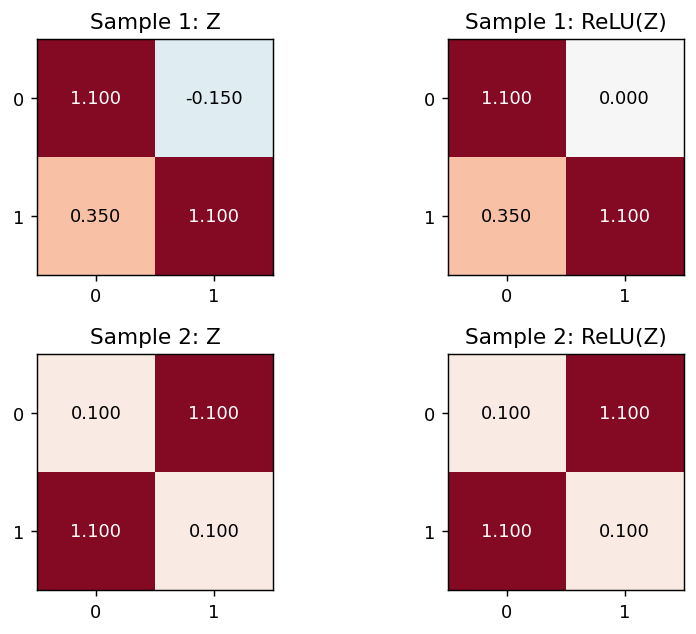

In [3]:
import matplotlib.pyplot as plt
from IPython.display import display, Image
from io import BytesIO
def show_figure(fig):
    buffer=BytesIO()
    fig.savefig(buffer,format='png',dpi=130,bbox_inches='tight')
    display(Image(data=buffer.getvalue()))
    plt.close(fig)
fig, axes = plt.subplots(2,2,figsize=(7,5))
for i in range(2):
    for j,values in enumerate([Z[i,0],H[i,0]]):
        axes[i,j].imshow(values,cmap='RdBu_r',vmin=-1.2,vmax=1.2)
        axes[i,j].set_title(f'Sample {i+1}: ' + ['Z','ReLU(Z)'][j])
        axes[i,j].set_xticks([0,1]); axes[i,j].set_yticks([0,1])
        for (r,c),value in np.ndenumerate(values):
            axes[i,j].text(c,r,f'{value:.3f}',ha='center',va='center',color='white' if abs(value)>.8 else 'black')
fig.tight_layout();show_figure(fig)

## 2 真正更新并做下一次前向
本单元仅有五参数，没有额外线性头。Fraction账本独立于NumPy卷积函数，用于每次状态核验。

updated K,b: [[[[ 0.513125  -0.2334375]
   [ 0.263125   0.513125 ]]]] [0.1296875]
next Z: [[[ 1.1559375 -0.0740625]
  [ 0.4225     1.1559375]]

 [[ 0.159375   1.1559375]
  [ 1.1559375  0.159375 ]]]
next pred/loss: [0.68359375 0.65765625] 0.03772647705078127
three exact-ledger mean losses: ['229/5120', '3090553/81920000', '7236578873/209715200000']


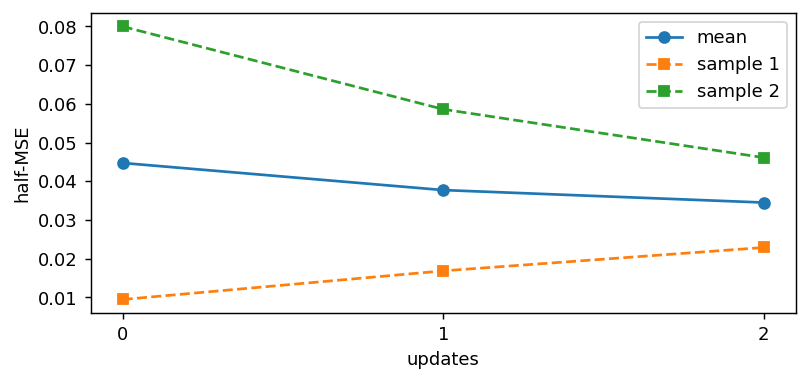

In [4]:
K1=K-.2*dK; b1=b-.2*db
Z1=experiment.conv_forward(X,K1,b1);p1=np.maximum(Z1,0).mean((1,2,3));l1=np.mean((p1-target)**2)/2
print('updated K,b:',K1,b1);print('next Z:',Z1[:,0]);print('next pred/loss:',p1,l1)
ledger=experiment.hand_ledger()
np.testing.assert_allclose(p1,[s['pred']['float'] for s in ledger[1]['samples']],atol=1e-14)
print('three exact-ledger mean losses:',[s['loss']['exact'] for s in ledger])
fig, ax=plt.subplots(figsize=(7,3))
ax.plot(range(3),[s['loss']['float'] for s in ledger],'o-',label='mean')
for i in range(2):ax.plot(range(3),[s['samples'][i]['loss']['float'] for s in ledger],'s--',label=f'sample {i+1}')
ax.set(xlabel='updates',ylabel='half-MSE',xticks=[0,1,2]);ax.legend();show_figure(fig)

## 3 新进程测试以外，Notebook也重新执行全部实验
run会重做80次NumPy与PyTorch更新并用最小二乘参照；不是加载旧结果冒充执行。参考数值只用于执行后比较。

In [5]:
with tempfile.TemporaryDirectory() as output:
    fresh=experiment.run(output)
    saved=json.loads((Path(output)/'results.json').read_text())
    if fresh != saved:raise RuntimeError('结果保存后读取不一致')
reference=json.loads((ROOT/'outputs/results.json').read_text())
def compare(a,b,path='root'):
    if isinstance(a,dict):
        if a.keys()!=b.keys():raise ValueError('key mismatch '+path)
        for key in a:compare(a[key],b[key],path+'.'+key)
    elif isinstance(a,list):
        if len(a)!=len(b):raise ValueError('length mismatch '+path)
        for i,(x,y) in enumerate(zip(a,b)):compare(x,y,path+f'[{i}]')
    elif isinstance(a,float):np.testing.assert_allclose(a,b,atol=1e-12,rtol=1e-10,err_msg=path)
    elif a!=b:raise ValueError('value mismatch '+path)
for key in ['hand','symmetry','learning']:compare(fresh[key],reference[key],key)
print('全部账本、探针、80步轨迹、测试预测已重算并对齐')
print('training/test/LS:',fresh['learning']['train_half_mse'],fresh['learning']['test_half_mse'],fresh['learning']['least_squares_train_half_mse'])

全部账本、探针、80步轨迹、测试预测已重算并对齐
training/test/LS: 0.0018041428092616738 0.0018397268945671646 0.0012427988588263339


## 4 等变条件，不只看一张差图
零边界全图和预定内部必须同时报告。步幅2输入移1格没有整数输出平移对应，两种硬对齐只是诊断。

zero_stride1_full coordinates= 64 max= 4.5 rmse= 1.2374368670764582
zero_stride1_interior coordinates= 30 max= 0.0 rmse= 0.0
circular_stride1 coordinates= 64 max= 0.0 rmse= 0.0
circular_stride2_shift2 coordinates= 16 max= 0.0 rmse= 0.0
circular_stride2_shift1_vs_shift0 coordinates= 16 max= 14.5 rmse= 6.576473218982953
circular_stride2_shift1_vs_shift1 coordinates= 16 max= 9.0 rmse= 4.130677910464576
circular_relu coordinates= 64 max= 0.0 rmse= 0.0


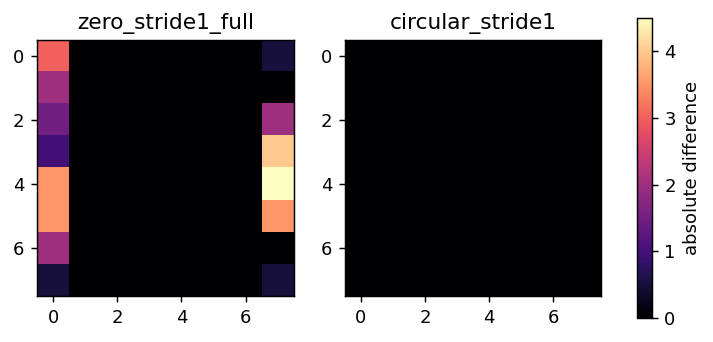

scalar heads: {'circular_gap': [2.4765625, 2.4765625], 'zero_gap': [2.390625, 2.1171875], 'circular_position_weighted': [86.1328125, 84.296875]}


In [6]:
for row in fresh['symmetry']['rows']:
    print(row['case'], 'coordinates=',row['coordinates'], 'max=',row['max_abs'], 'rmse=',row['rmse'])
fig,axes=plt.subplots(1,2,figsize=(7,3))
for ax,name in zip(axes,['zero_stride1_full','circular_stride1']):
    im=ax.imshow(fresh['symmetry']['arrays'][name]['difference'],cmap='magma',vmin=0,vmax=4.5)
    ax.set_title(name)
fig.colorbar(im,ax=axes.ravel().tolist(),label='absolute difference');show_figure(fig)
print('scalar heads:',fresh['symmetry']['heads'])

## 5 真实80步学习与保留的优化误差
固定协议不搜索、不早停、不挑种子。训练和测试只是本合成分布结果，不代表真实图像任务。

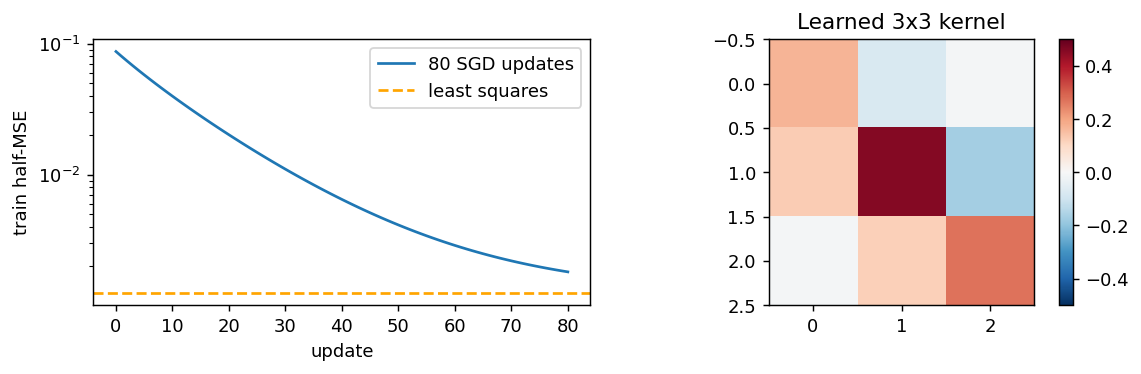

GD-to-LS parameter max difference: 0.04305517695093125
framework per-step max gap: 4.440892098500626e-16
constant test baseline: 0.07777710165207236


In [7]:
learning=fresh['learning'];trace=learning['trace']
fig,axes=plt.subplots(1,2,figsize=(9,3))
axes[0].semilogy([v['step'] for v in trace],[v['loss'] for v in trace],label='80 SGD updates')
axes[0].axhline(learning['least_squares_train_half_mse'],ls='--',color='orange',label='least squares')
axes[0].set(xlabel='update',ylabel='train half-MSE');axes[0].legend()
im=axes[1].imshow(learning['learned_kernel'],vmin=-.5,vmax=.5,cmap='RdBu_r');axes[1].set_title('Learned 3x3 kernel');fig.colorbar(im,ax=axes[1]);fig.tight_layout();show_figure(fig)
print('GD-to-LS parameter max difference:',learning['gd_to_least_squares_max_abs'])
print('framework per-step max gap:',learning['torch_max_abs_gap'])
print('constant test baseline:',learning['constant_test_half_mse'])

## 6 独立测试与学习问题
以下unittest不依赖Python assert，因此-O仍可检查。完成后解释：哪里是数学前提、哪里是实现证据、哪里只是固定经验结果？

In [8]:
import unittest, test_experiment
suite=unittest.defaultTestLoader.loadTestsFromModule(test_experiment)
check=unittest.TextTestRunner(verbosity=1).run(suite)
if not check.wasSuccessful():raise RuntimeError('contract checks failed')
print('完成。浏览器Jupyter UI、GPU与跨平台重装未在本次核验范围内。')

.

.

.

.

.

...

.

.

.

----------------------------------------------------------------------
Ran 9 tests in 0.246s

OK


完成。浏览器Jupyter UI、GPU与跨平台重装未在本次核验范围内。
